In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [29]:
from datasets import load_dataset

emotion_dataset = load_dataset('dair-ai/emotion')
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [30]:
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

label_names = emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [31]:
df_train = pd.DataFrame({'text':train_text, 'label':[label_names[i] for i in train_label]})
df_test = pd.DataFrame({'text':test_text, 'label': [label_names[i] for i in test_label]})

df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [33]:
order = df_train['label'].value_counts().index

In [34]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
# Necessary NLTK resources download karein
nltk.download('punkt')

# Common Contractions Dictionary
CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'ve": " have",
    "'m": " am"
  }

def preprocess(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    for contraction, replacement in CONTRACTIONS.items():
        text = text.replace(contraction, replacement)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    word_tokens = word_tokenize(text)

    return " ".join(word_tokens)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [35]:
df_train['text'] = df_train['text'].apply(preprocess)
df_test['text'] = df_test['text'].apply(preprocess)

In [36]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


<Axes: xlabel='label', ylabel='count'>

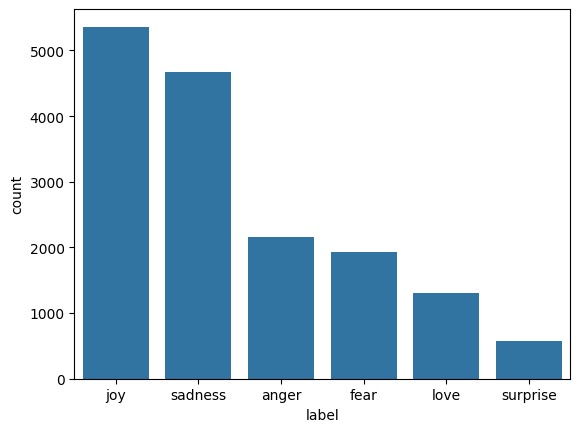

In [37]:
sns.countplot(data=df_train, x='label', order=order)

In [38]:
#Data Preprocessing Using NLP
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)



In [39]:
num_classes = len(label_names)
num_classes

6

In [40]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [42]:
# Simple RNN Model

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout,Bidirectional
from tensorflow.keras.optimizers import Adam


rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 100, input_length = 50, mask_zero=True),
    Bidirectional(SimpleRNN(units = 64, return_sequences = True)),
    Dropout(0.3),
    Bidirectional(SimpleRNN(units = 64)),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])


In [44]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f'Test Loss: {rnn_loss}, Test Accuracy: {rnn_accuracy}')

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3313 - loss: 1.6225 - val_accuracy: 0.5340 - val_loss: 1.1485
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7619 - loss: 0.6354 - val_accuracy: 0.7480 - val_loss: 0.7364
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8874 - loss: 0.3002 - val_accuracy: 0.8440 - val_loss: 0.4950
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9298 - loss: 0.1813 - val_accuracy: 0.8310 - val_loss: 0.5338
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9323 - loss: 0.1762 - val_accuracy: 0.8315 - val_loss: 0.5685
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9529 - loss: 0.1231 - val_accuracy: 0.8540 - val_loss: 0.5366
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8440 - loss: 0.4950
Test Loss: 0.494988352060318, Test Accuracy: 0.843999981880188


In [45]:
#LSTM Model
from tensorflow.keras.layers import LSTM,GRU
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 100, input_length = 50, mask_zero=True),
    Bidirectional(LSTM(units = 64, return_sequences = True)),
    Dropout(0.3),
    Bidirectional(LSTM(units = 32)),
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])


In [46]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f'Test Loss: {lstm_loss}, Test Accuracy: {lstm_accuracy}')

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5760 - loss: 1.1746 - val_accuracy: 0.8350 - val_loss: 0.5336
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9047 - loss: 0.2858 - val_accuracy: 0.8840 - val_loss: 0.3427
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9434 - loss: 0.1637 - val_accuracy: 0.9025 - val_loss: 0.3037
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9634 - loss: 0.1068 - val_accuracy: 0.9010 - val_loss: 0.3299
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9700 - loss: 0.0885 - val_accuracy: 0.9040 - val_loss: 0.3096
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9734 - loss: 0.0771 - val_accuracy: 0.9040 - val_loss: 0.3447
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9025 - loss: 0.3037
Test Loss: 0.30366918444633484, Test Accuracy: 0.9024999737739563


In [47]:
#GRU Model

gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50, mask_zero=True),
    Bidirectional(GRU(units = 64, return_sequences = True)),
    Dropout(0.3),
    Bidirectional(GRU(units = 32)),
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [48]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f'Test Loss: {gru_loss}, Test Accuracy: {gru_accuracy}')

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5721 - loss: 1.0905 - val_accuracy: 0.8825 - val_loss: 0.3633
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9237 - loss: 0.2106 - val_accuracy: 0.9110 - val_loss: 0.2443
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9546 - loss: 0.1154 - val_accuracy: 0.9205 - val_loss: 0.2303
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9715 - loss: 0.0729 - val_accuracy: 0.9205 - val_loss: 0.2533
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9778 - loss: 0.0587 - val_accuracy: 0.9100 - val_loss: 0.2745
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9832 - loss: 0.0447 - val_accuracy: 0.9080 - val_loss: 0.3153
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9205 - loss: 0.2303
Test Loss: 0.23033761978149414, Test Accuracy: 0.9204999804496765


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


<Axes: >

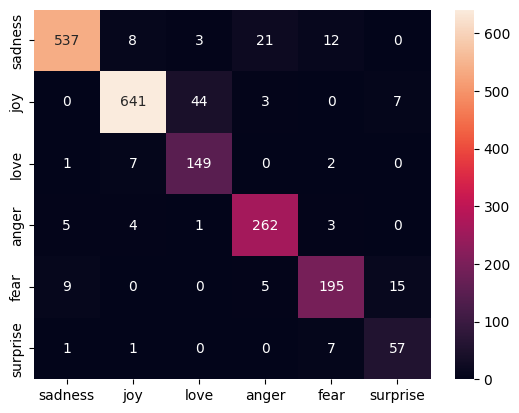

In [49]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(test_labels, np.argmax(gru_model.predict(padded_test_sequence), axis=1)), annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)

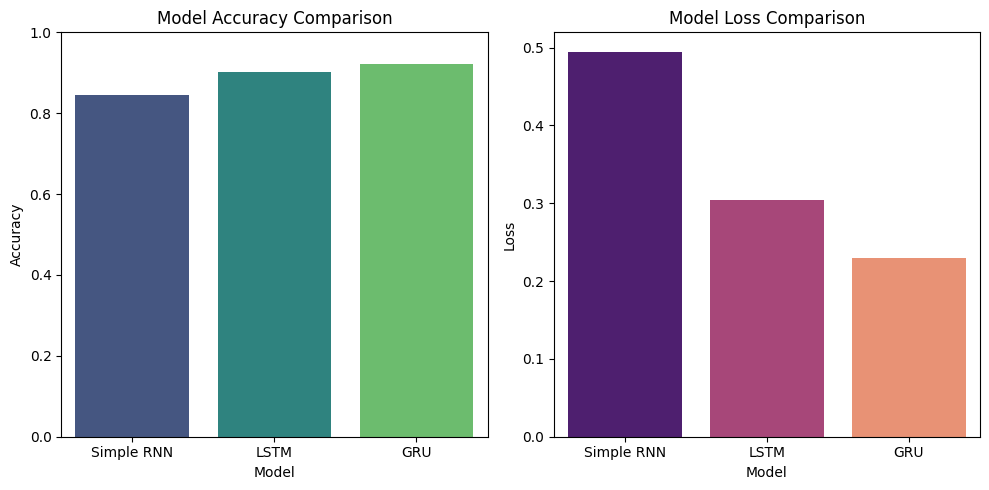

,Model,Accuracy,Loss
0,Simple RNN,0.8440,0.494988
1,LSTM,0.9025,0.303669
2,GRU,0.9205,0.230338


In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for comparison
model_names = ['Simple RNN', 'LSTM', 'GRU']
accuracies = [rnn_accuracy, lstm_accuracy, gru_accuracy]
losses = [rnn_loss, lstm_loss, gru_loss]

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Loss': losses
})

# Plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.0)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Loss', data=comparison_df, palette='magma')
plt.title('Model Loss Comparison')

plt.tight_layout()
plt.show()

display(comparison_df)

In [51]:
import os
import pickle

model_dir = "Artifacts"

os.makedirs(model_dir, exist_ok=True)

# Save Tokenizer
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)
#Save GRU Model
gru_model.save(os.path.join(model_dir, 'gru_model.keras'))

In [52]:
from google.colab import files

# Colab se direct PC me file download karein
files.download('Artifacts/gru_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>